In [189]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm

In [191]:
data = pd.read_csv('data/sunspots_yearly.csv', sep=';', header=None)
data = data.rename(columns={0: 'year', 1: 'sunspots'})
data = data[['year', 'sunspots']]
data['year'] = data['year'].astype(int)
data

,year,sunspots
0,1700,8.3
1,1701,18.3
2,1702,26.7
3,1703,38.3
4,1704,60.0
...,...,...
321,2021,29.6
322,2022,83.2
323,2023,125.5
324,2024,154.7


In [192]:
data['time'] = pd.to_datetime(data[['year']].assign(day=1, month=6))
data = data[['time', 'sunspots']]
START = 1700
data = data[data['time'].dt.year >= START]


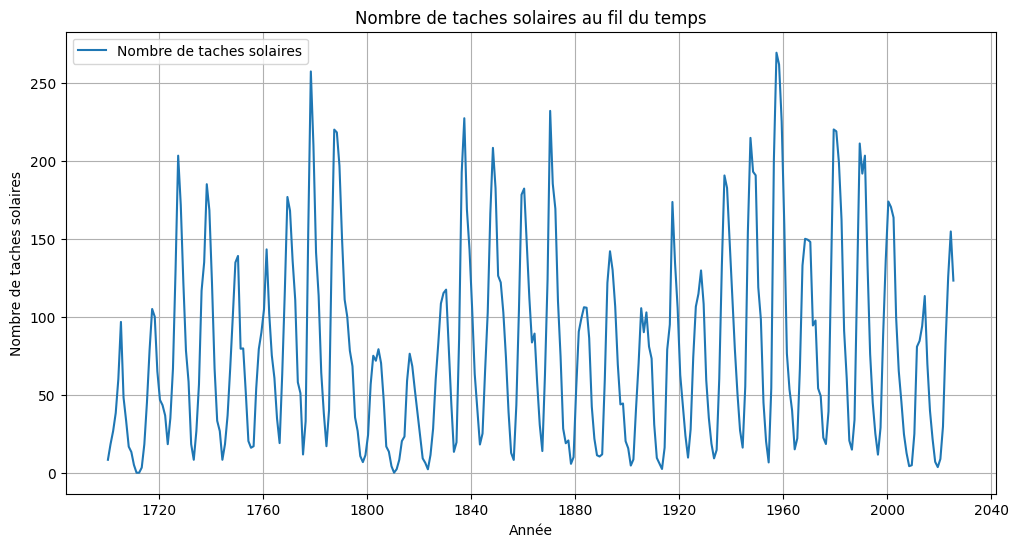

In [193]:
t = data['time']
sunspots = data['sunspots']
# Take on each 4 points to make the plot less dense
plt.figure(figsize=(12, 6))
plt.plot(t, sunspots, label='Nombre de taches solaires')
plt.title('Nombre de taches solaires au fil du temps')
plt.xlabel('Année')
plt.ylabel('Nombre de taches solaires')
plt.grid()
plt.legend()
plt.show()

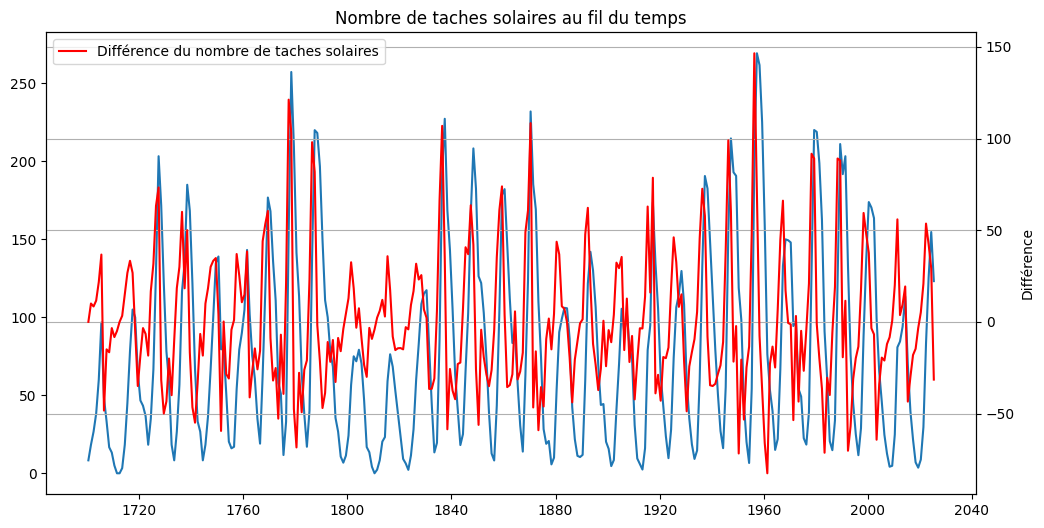

In [428]:
from ctw.tree import Tree, view_tree, TreeNode, __visualize_tree
from ctw.models import BivariateARTree, BivariateQuantizer

X = sunspots / 200
Y = sunspots.diff().fillna(0)

# Plot Y and X
plt.figure(figsize=(12, 6))
plt.plot(t, sunspots, label='Nombre de taches solaires')
ax1 = plt.twinx()
plt.plot(t, Y, label='Différence du nombre de taches solaires', color='red')
plt.title('Nombre de taches solaires au fil du temps')
plt.xlabel('Année')
plt.ylabel('Nombre de taches solaires')
ax1.set_ylabel('Différence')
plt.grid()
plt.legend()
plt.show()

# threshold_x = np.linspace(X.min(), X.max(), 15)
# threshold_y = [-0.5, 0.5]

# bq = BivariateQuantizer(thresholds=[threshold_x, threshold_y])

# tree = BivariateARTree(order = 4, max_depth=4, quantizer=bq, y_depth=1, beta=0.5)
# for i in range(10):
#     for i in tqdm.tqdm(range(len(X))):
#         x = X.iloc[i]
#         y = Y.iloc[i]
#         tree.observe(x_new=x, y_new=y)
# view_tree(tree.tree, quantizer=bq)

In [195]:
# # Make predicitons
# predictions = []
# truth = []
# for i in range(10, len(X) - 1):
#     x_new = X.iloc[i-3:i+1].to_list()
#     # y_new = Y.iloc[i-1:i].tolist()
#     # x_new = X.iloc[-13:-1:3].to_list()
#     y_new = [ - np.inf ] * 3 + Y.iloc[i:i+1].tolist()
#     history = np.array([x_new, y_new])
#     pred = tree.predict(history=history)
#     predictions.append(pred)
#     truth.append(X.iloc[i+1])

# plt.figure(figsize=(12, 6))
# # plt.plot(t[10:], Y[10:], label='Différence du nombre de taches solaires', color='red')
# plt.plot(t[10:-1], predictions, label='Prédictions du modèle', color='blue')
# plt.title('Prédictions du modèle vs réalité')
# plt.xlabel('Année')
# plt.ylabel('Différence du nombre de taches solaires')
# plt.grid()
# plt.legend()
# plt.show()

# # compute rmse
# from sklearn.metrics import mean_squared_error
# rmse = np.sqrt(mean_squared_error(predictions, truth))
# print("RMSE : ", rmse)

# # Conpute naive predictor rmse
# naive_predictions = Y.shift(1).fillna(0)
# rmse_naive = np.sqrt(mean_squared_error(Y[10:], naive_predictions[10:]))
# print("RMSE du prédicteur naïf : ", rmse_naive)




threshold_x :  [0.         0.09617857 0.19235714 0.28853571 0.38471429 0.48089286
 0.57707143 0.67325    0.76942857 0.86560714 0.96178571 1.05796429
 1.15414286 1.25032143 1.3465    ]
threshold_y :  [-0.5, 0.5]


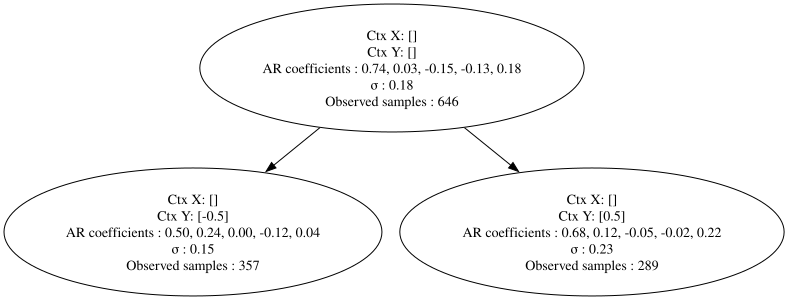

In [431]:
from ctw.models import BivariateARTreeBis, Quantizer
from ctw.tree import Tree, print_tree
import numpy as np

train_proportion = 2/3
train_range = 0, int(len(X) * train_proportion)
test_range = int(len(X) * train_proportion), len(X) - 1

threshold_x = np.linspace(X.min(), X.max(), 15)
threshold_y = [-0.5, 0.5]
print("threshold_x : ", threshold_x)
print("threshold_y : ", threshold_y)

x_quantizer = Quantizer(thresholds=threshold_x)
y_quantizer = Quantizer(thresholds=threshold_y)
order = 4

seq = [1, 0]
btree = BivariateARTreeBis(quantizer_seq=seq, x_quantizer=x_quantizer, y_quantizer=y_quantizer, order=order, constant_term=True, beta=0.5)
for i in range(3):
    for i in range(*train_range):
        x = X.iloc[i]
        y = Y.iloc[i]
        btree.observe(x_new=x, y_new=y)
view_tree(btree.tree, quantizer_seq=seq, x_quantizer=x_quantizer, y_quantizer=y_quantizer, min_observed_samples=0)

In [432]:
predictions = []
truth = []
for i in range(*test_range):
    x_history = X.iloc[i-order + 1:i+1].to_list()
    y_history = Y.iloc[i-order + 1:i+1].to_list()
    pred = btree.predict(x_history=x_history, y_history=y_history)
    predictions.append(pred)
    truth.append(X.iloc[i+1])

# Compute rmse
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(predictions, truth))
print("RMSE : ", rmse)


RMSE :  0.1524642181152129


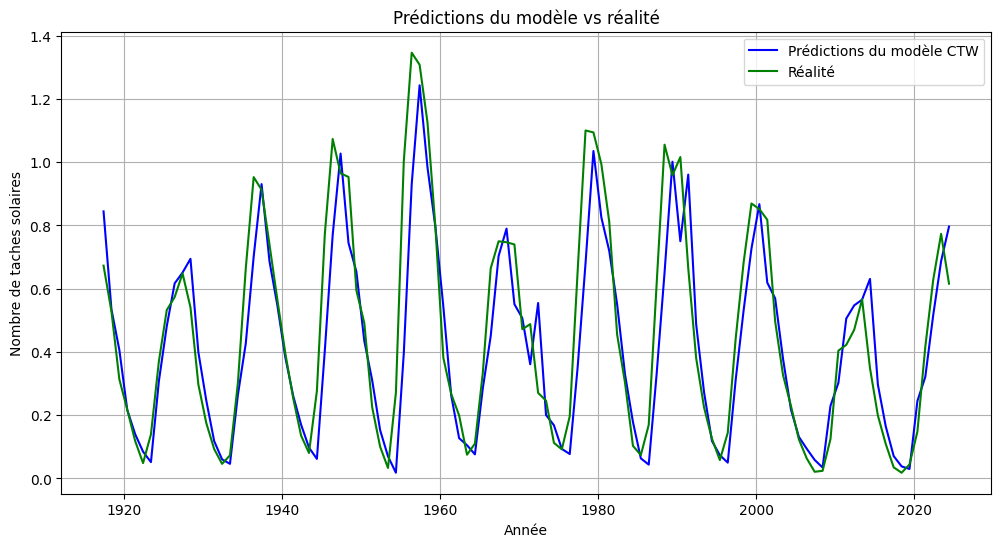

In [433]:
# plot predictions vs truth
LIMIT = 200
plt.figure(figsize=(12, 6))
plt.plot(t[test_range[0]:test_range[1]], predictions, label='Prédictions du modèle CTW', color='blue')
plt.plot(t[test_range[0]:test_range[1]], truth, label='Réalité', color='green')
plt.title('Prédictions du modèle vs réalité')
plt.xlabel('Année')
plt.ylabel('Nombre de taches solaires')
plt.grid()
plt.legend()
plt.show()